# 06. 시각화 (Step 7)

`src/visualize.py`의 함수를 호출하여 요구사항 §4 Step 7의 8종 차트를 생성한다.
모든 matplotlib 차트는 한글 폰트 설정을 거치며, `results/figures/`에 300dpi 이상 PNG로 저장된다.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
from IPython.display import Image, display, IFrame

from feature_engineering import build_region_features, BUZ_LIST, AGE_LABEL_LIST, REGION_KEYS
from scoring import classify_segments
from external_data import load_moj_visa_by_region, compute_visa_group_shares, merge_segment_with_visa, VISA_GROUPS
import visualize as viz

chosen_font = viz.setup_korean_font()
print(f"[OK] 한글 폰트 설정: {chosen_font}")


[OK] 한글 폰트 설정: Noto Serif CJK JP


## 6-1. 시각화에 필요한 데이터 재구성

03·04번 노트북과 동일한 로직으로 세그먼트 분류 + 체류자격 결합 결과를 다시 만든다 (중복 저장 방지, 함수 재사용).

In [2]:
foreign_df = pd.read_csv('../data/processed/foreign_consumption_clean.csv', dtype={'STRD_YYMM': str})
features = build_region_features(foreign_df)
segment_df, meta = classify_segments(features)

moj = load_moj_visa_by_region()
shares = compute_visa_group_shares(moj)
merged_visa = merge_segment_with_visa(segment_df, shares)

print(f"세그먼트 지역 수: {len(segment_df)}, 실루엣 스코어: {meta['best_silhouette']:.3f} (K={meta['best_k']})")


세그먼트 지역 수: 255, 실루엣 스코어: 0.206 (K=3)


## 6-2. 차트 1~6 (matplotlib, PNG)

In [3]:
paths = [
    viz.plot_segment_industry_composition(segment_df, BUZ_LIST),
    viz.plot_segment_age_distribution(segment_df, AGE_LABEL_LIST),
    viz.plot_monthly_trend(foreign_df, segment_df),
    viz.plot_cluster_scatter(segment_df, meta['best_silhouette'], meta['best_k']),
    viz.plot_visa_composition_by_segment(merged_visa, list(VISA_GROUPS.keys())),
    viz.plot_top15_regions(segment_df),
]
for p in paths:
    print(f"[OK] {p.name} ({p.stat().st_size/1024:.0f} KB)")


[OK] 01_segment_industry_composition.png (150 KB)
[OK] 02_segment_age_distribution.png (109 KB)
[OK] 03_monthly_trend.png (261 KB)
[OK] 04_cluster_scatter_pca.png (257 KB)
[OK] 05_visa_composition_by_segment.png (135 KB)
[OK] 06_top15_regions.png (241 KB)


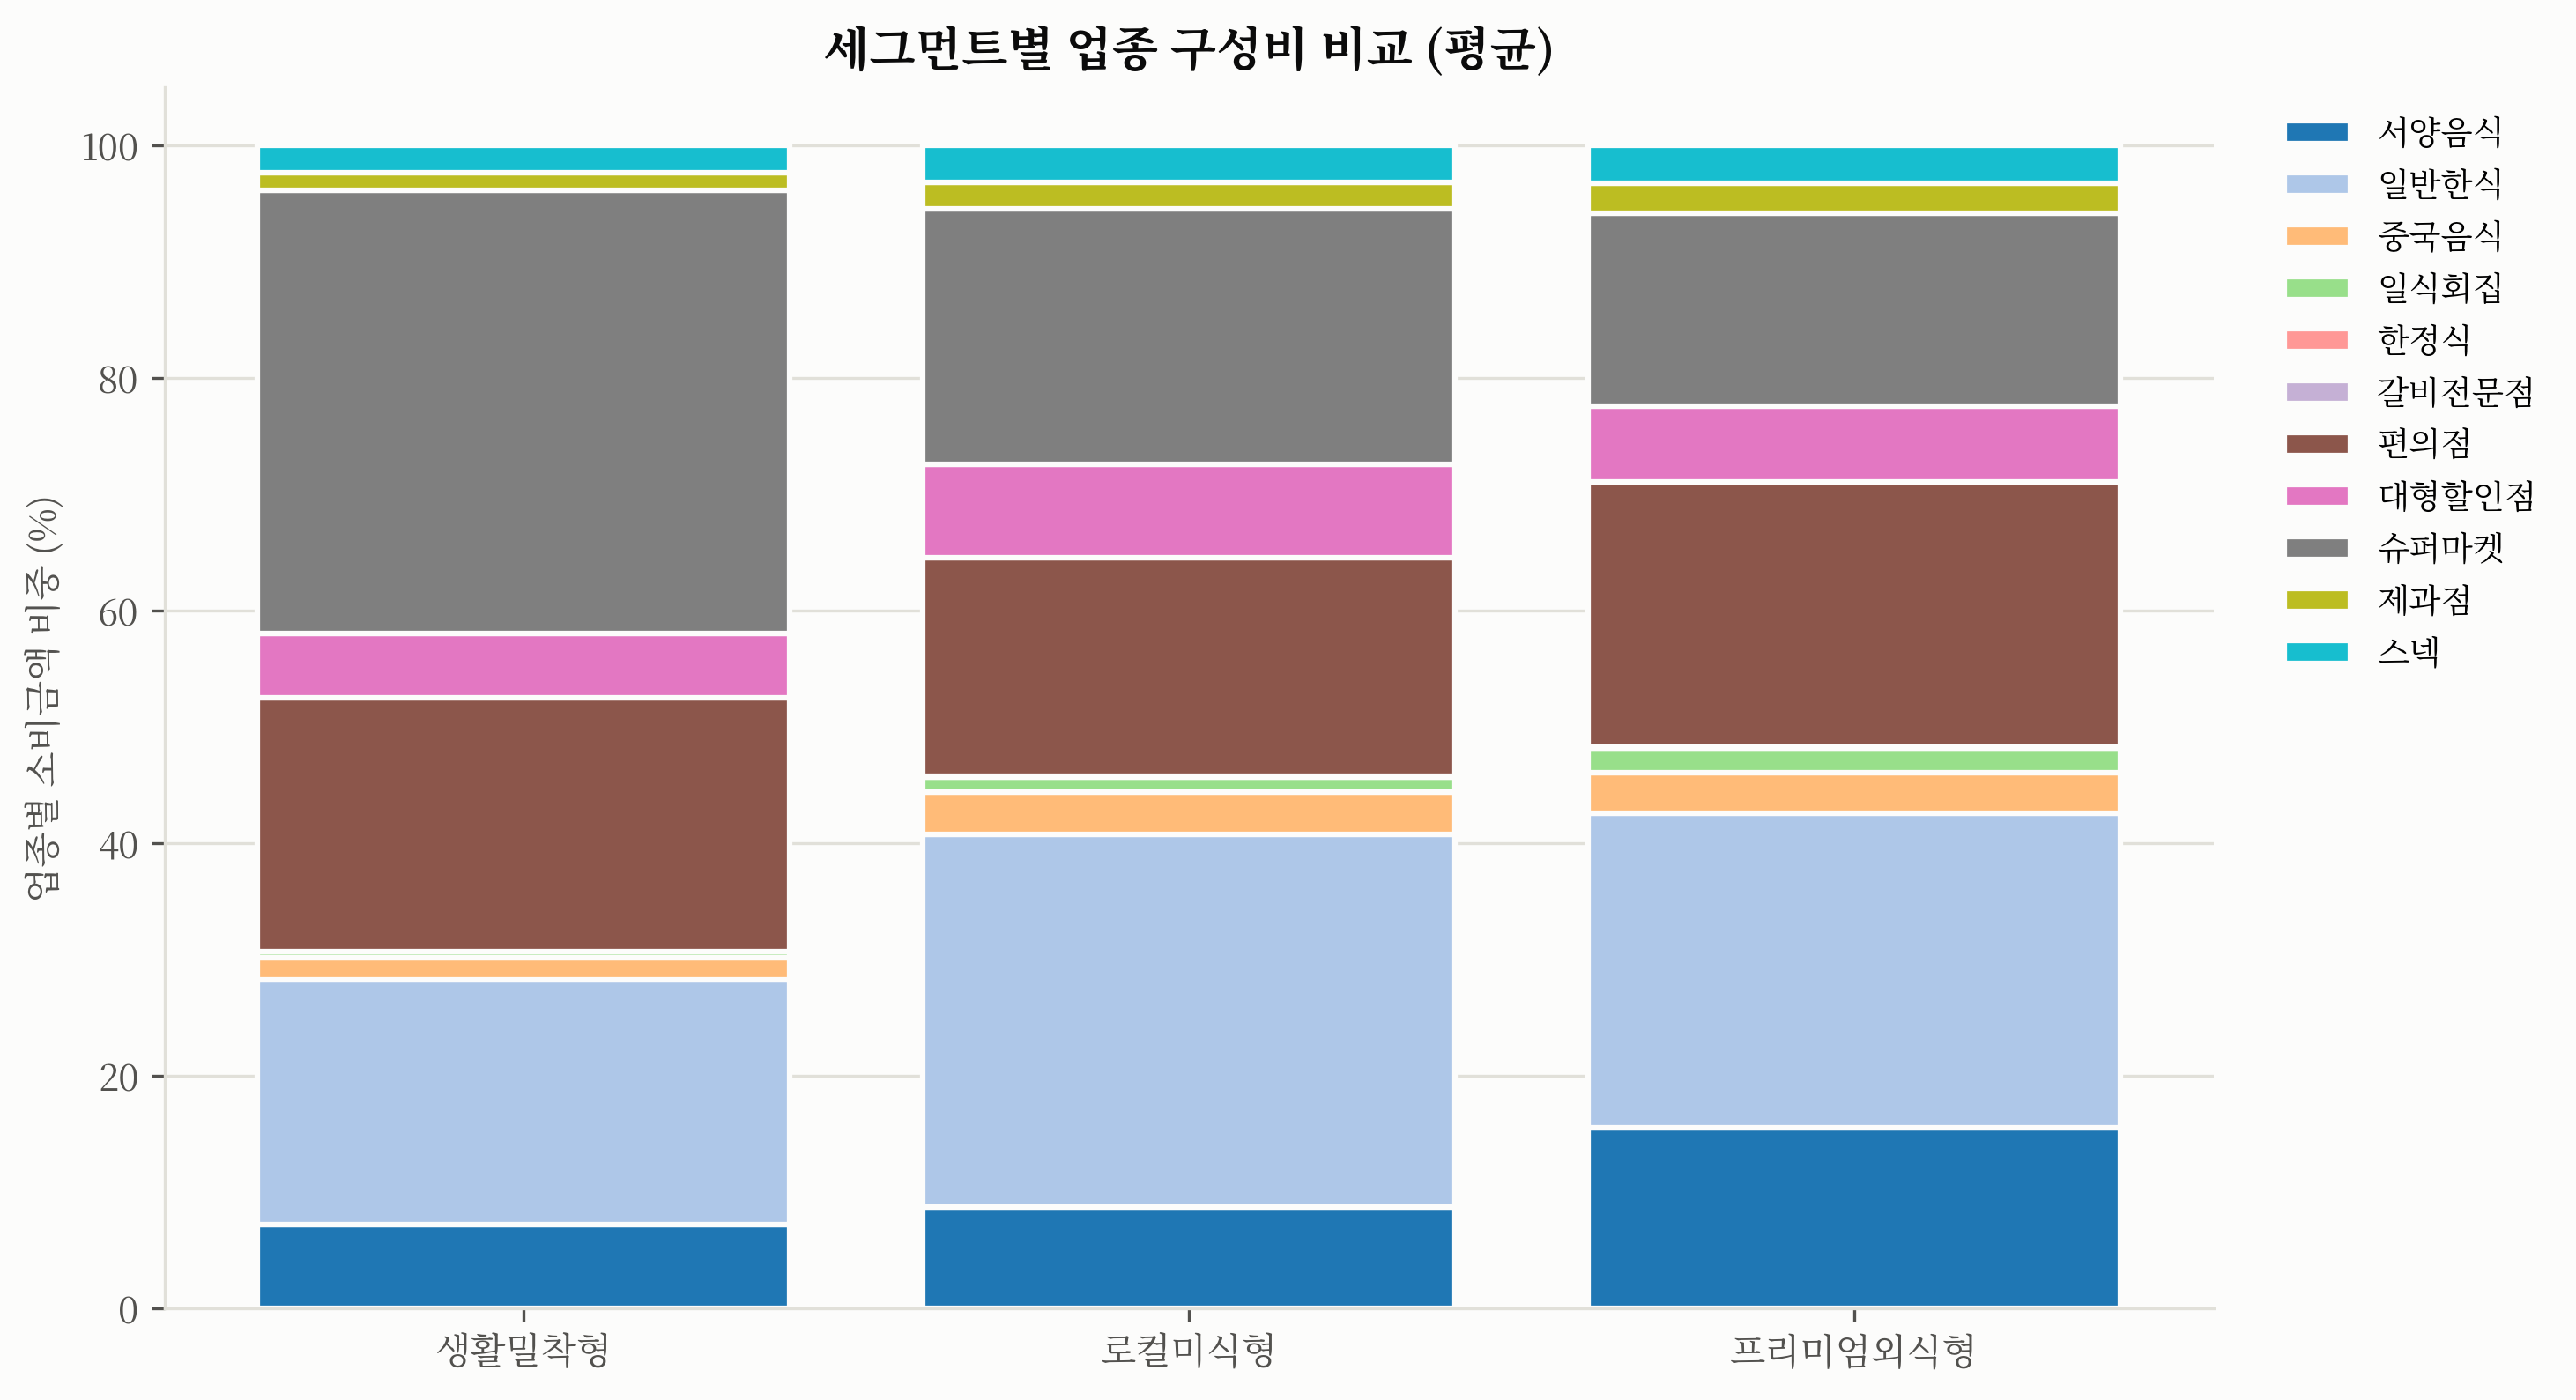

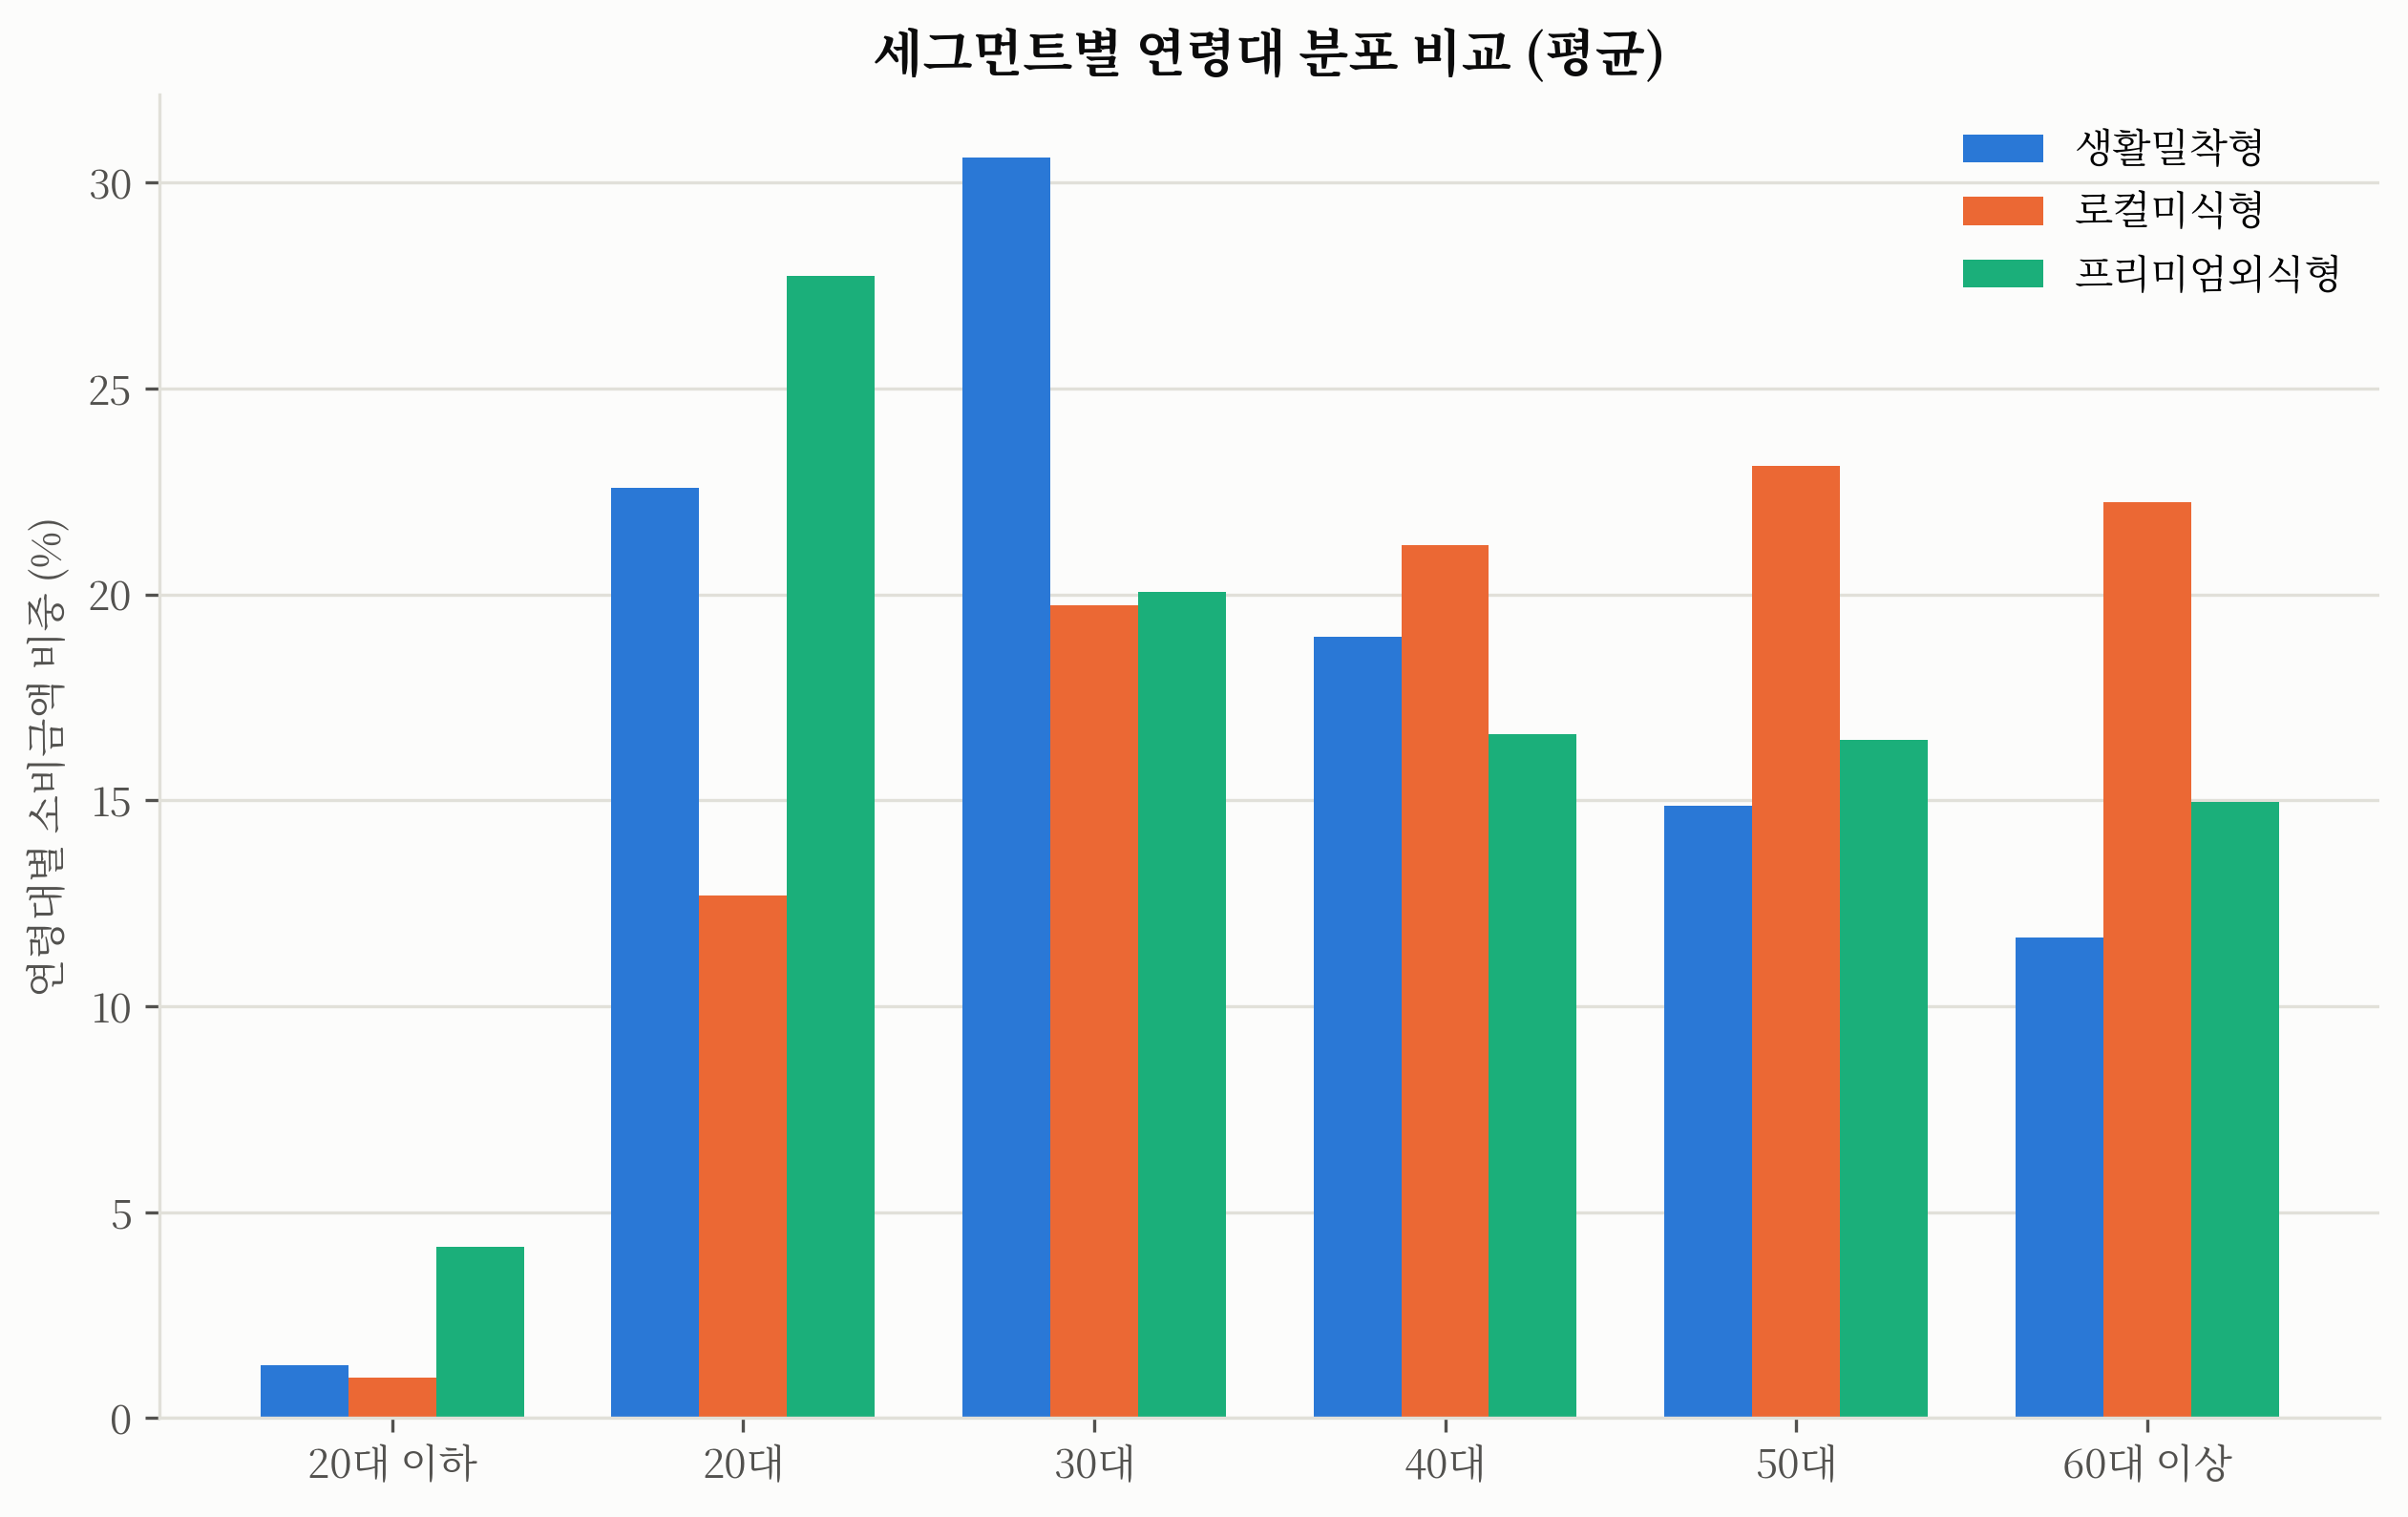

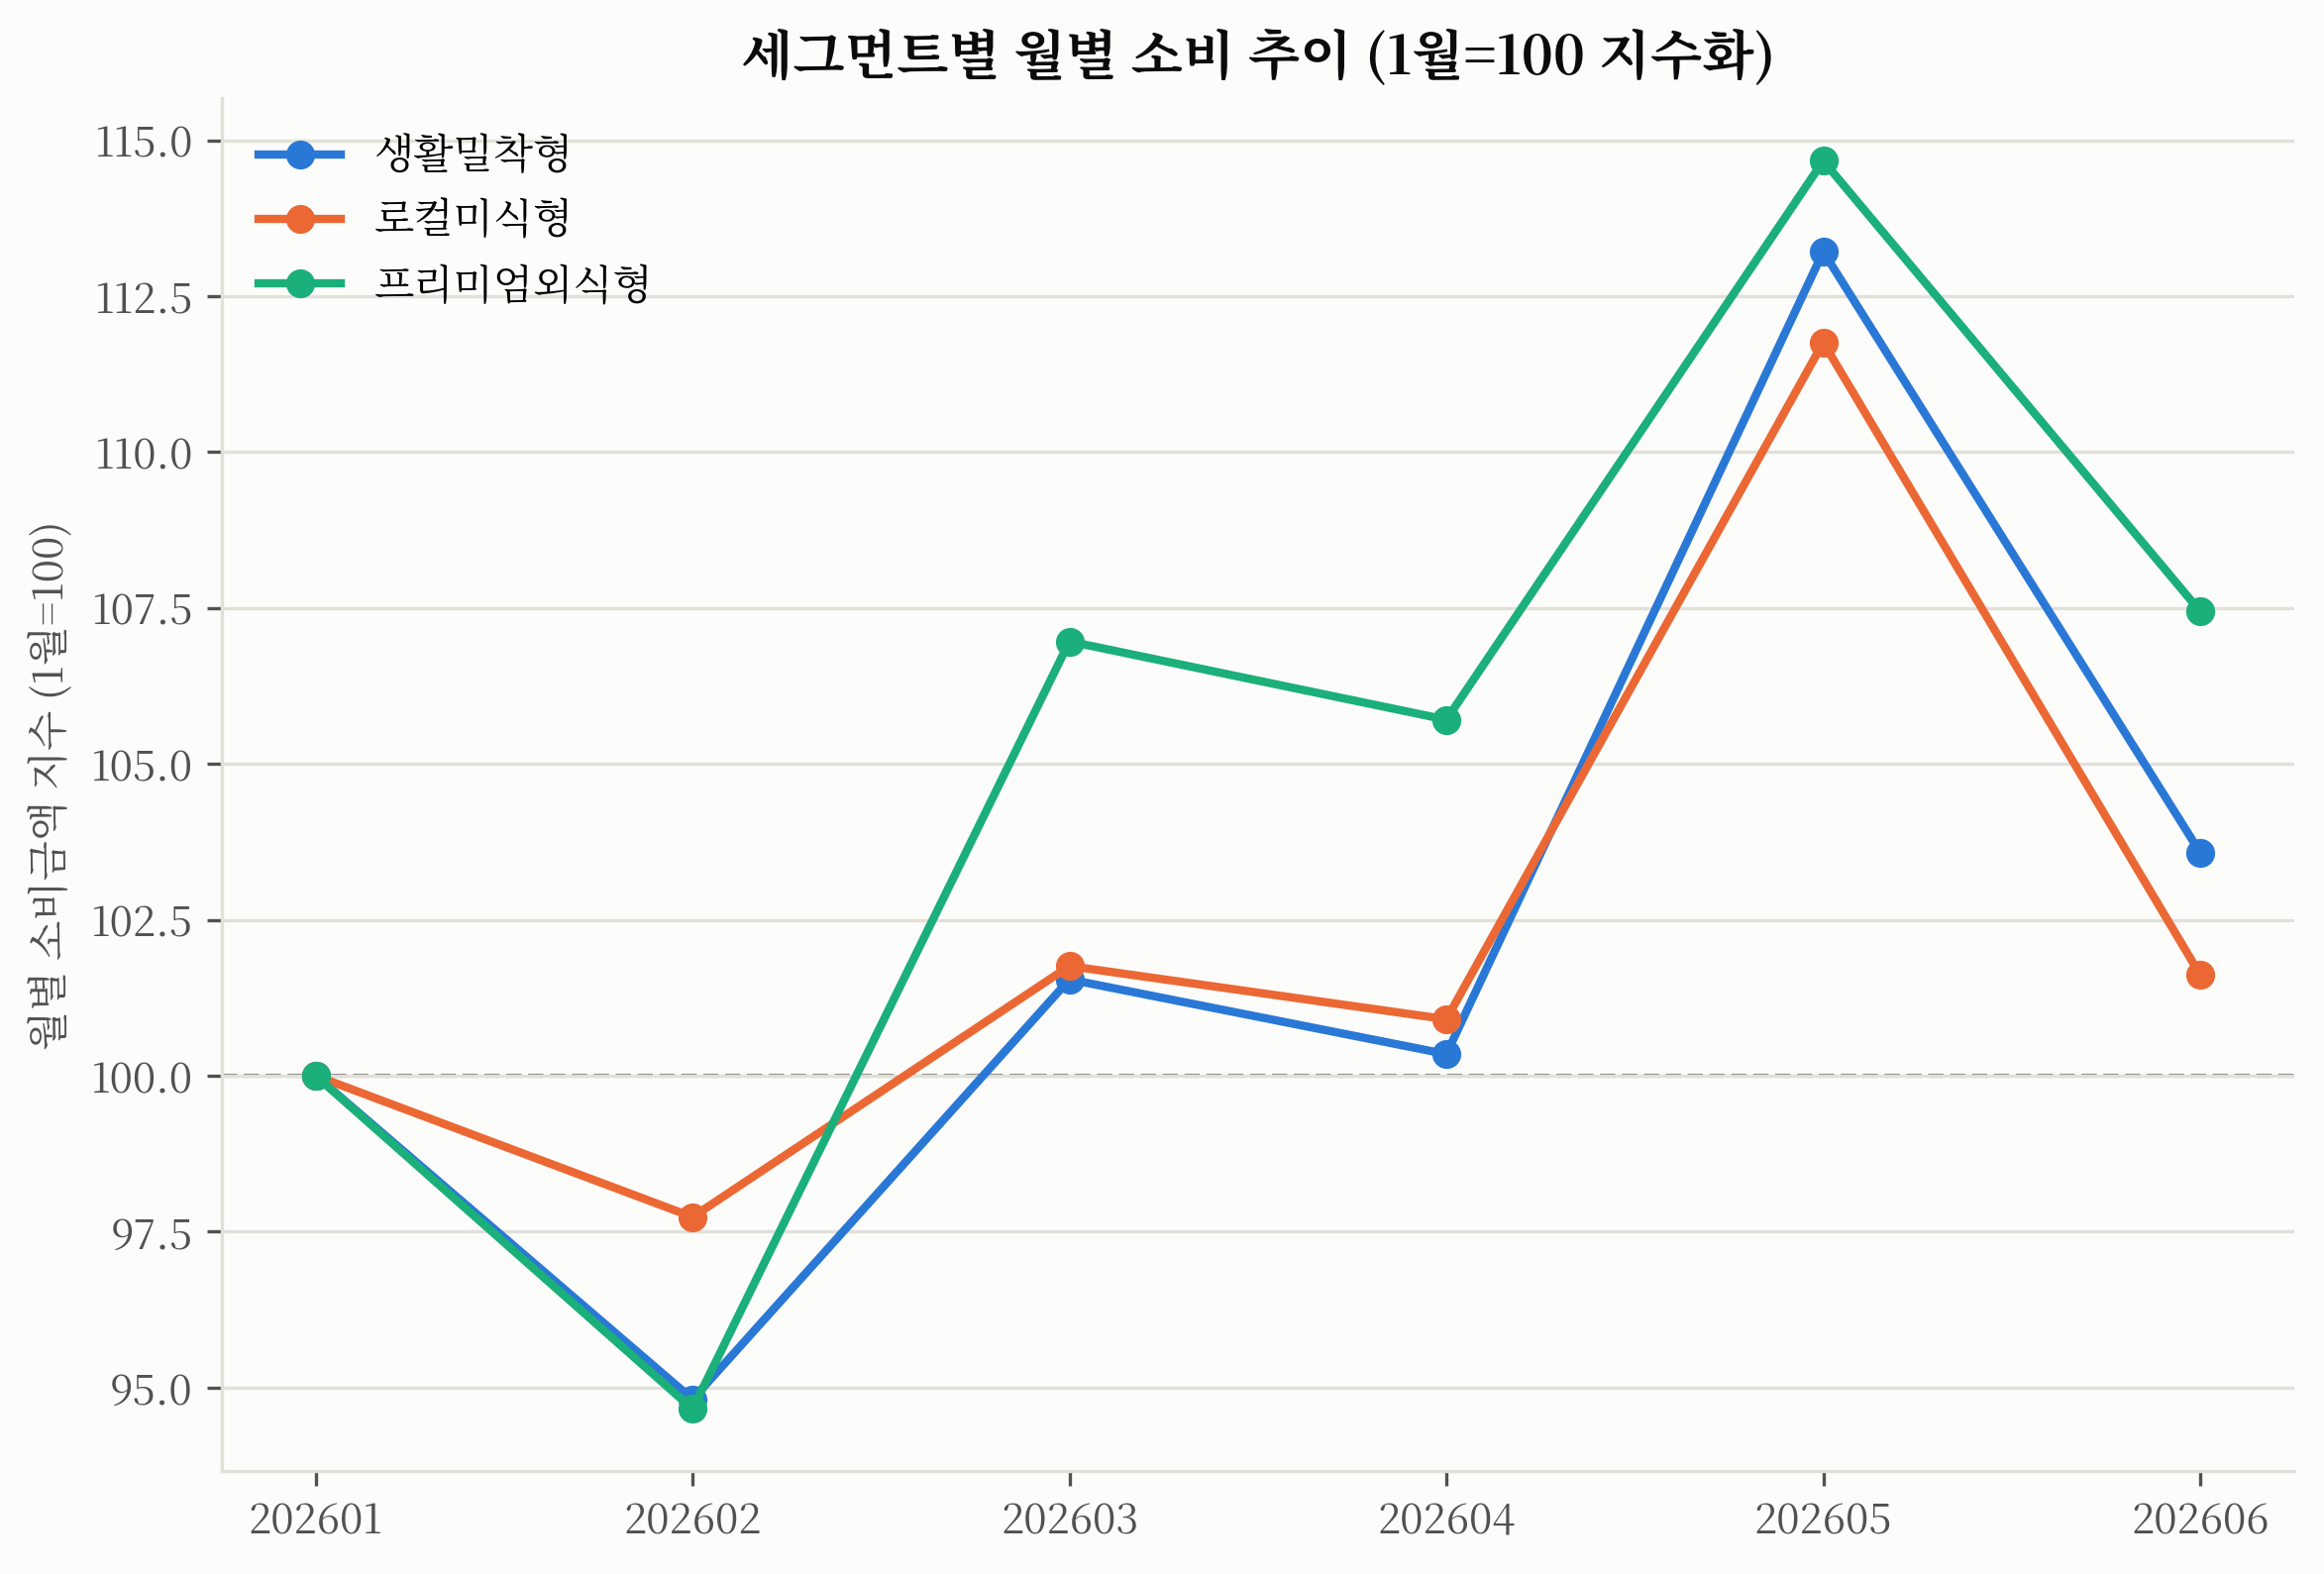

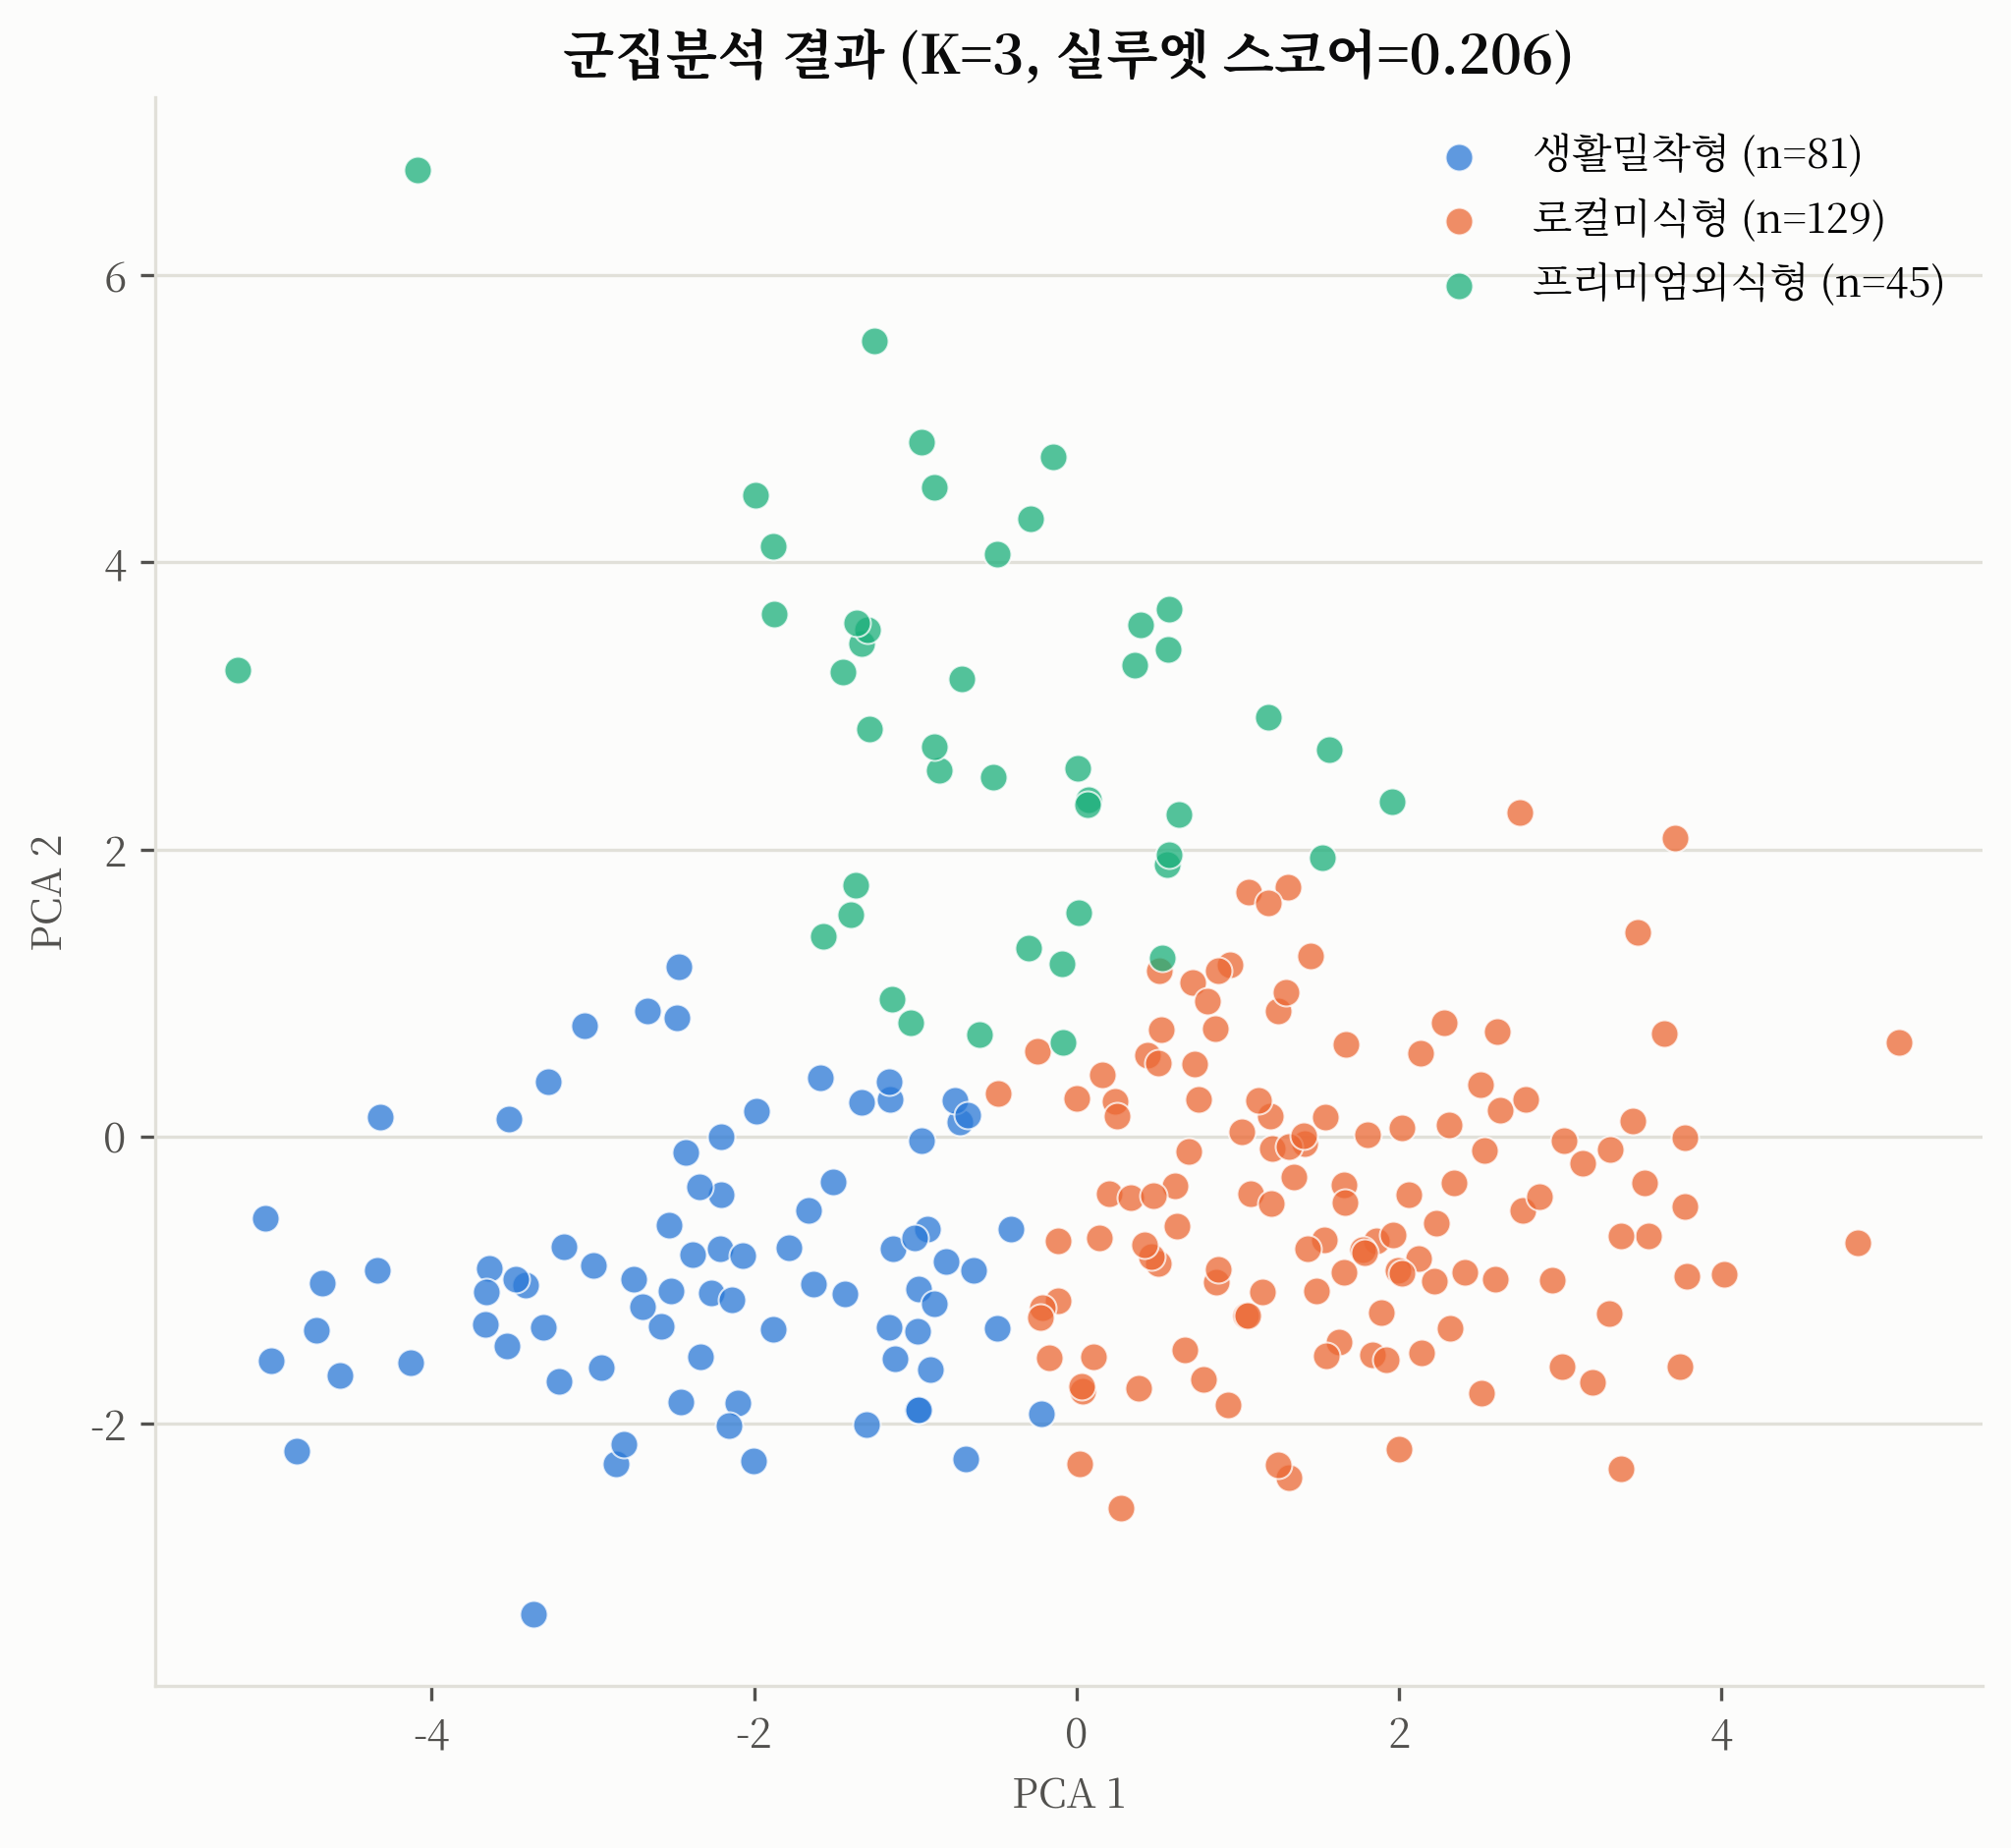

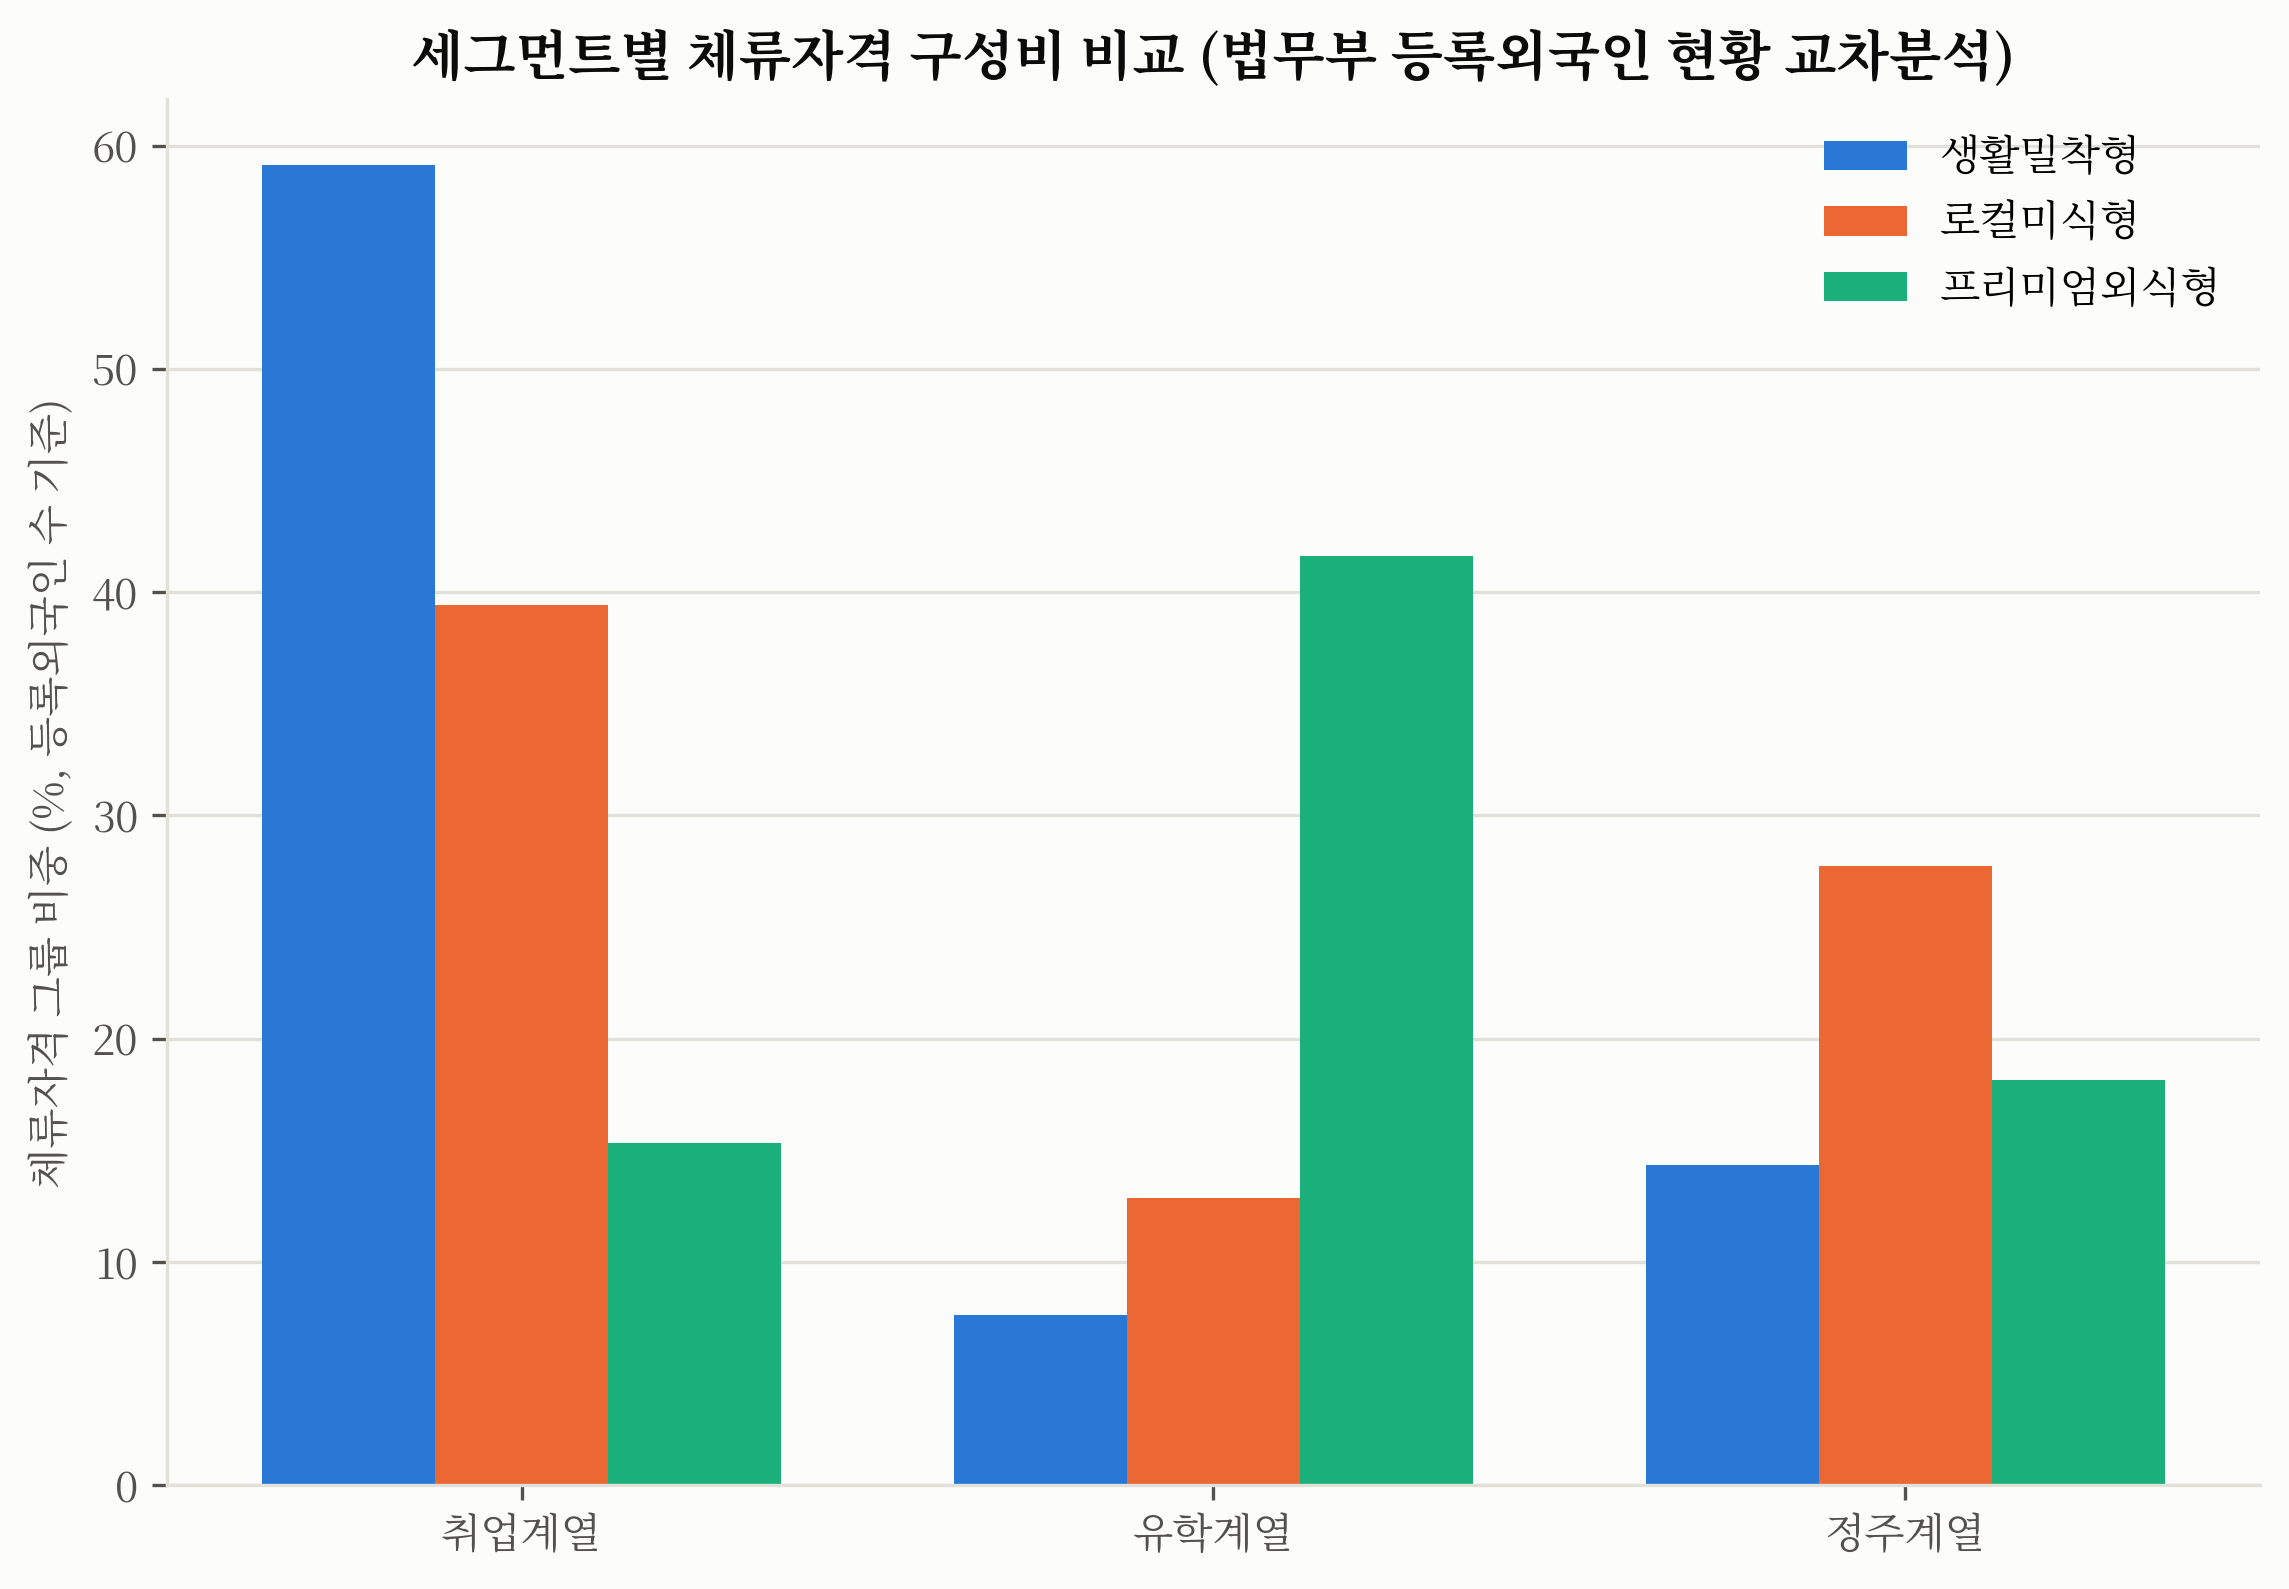

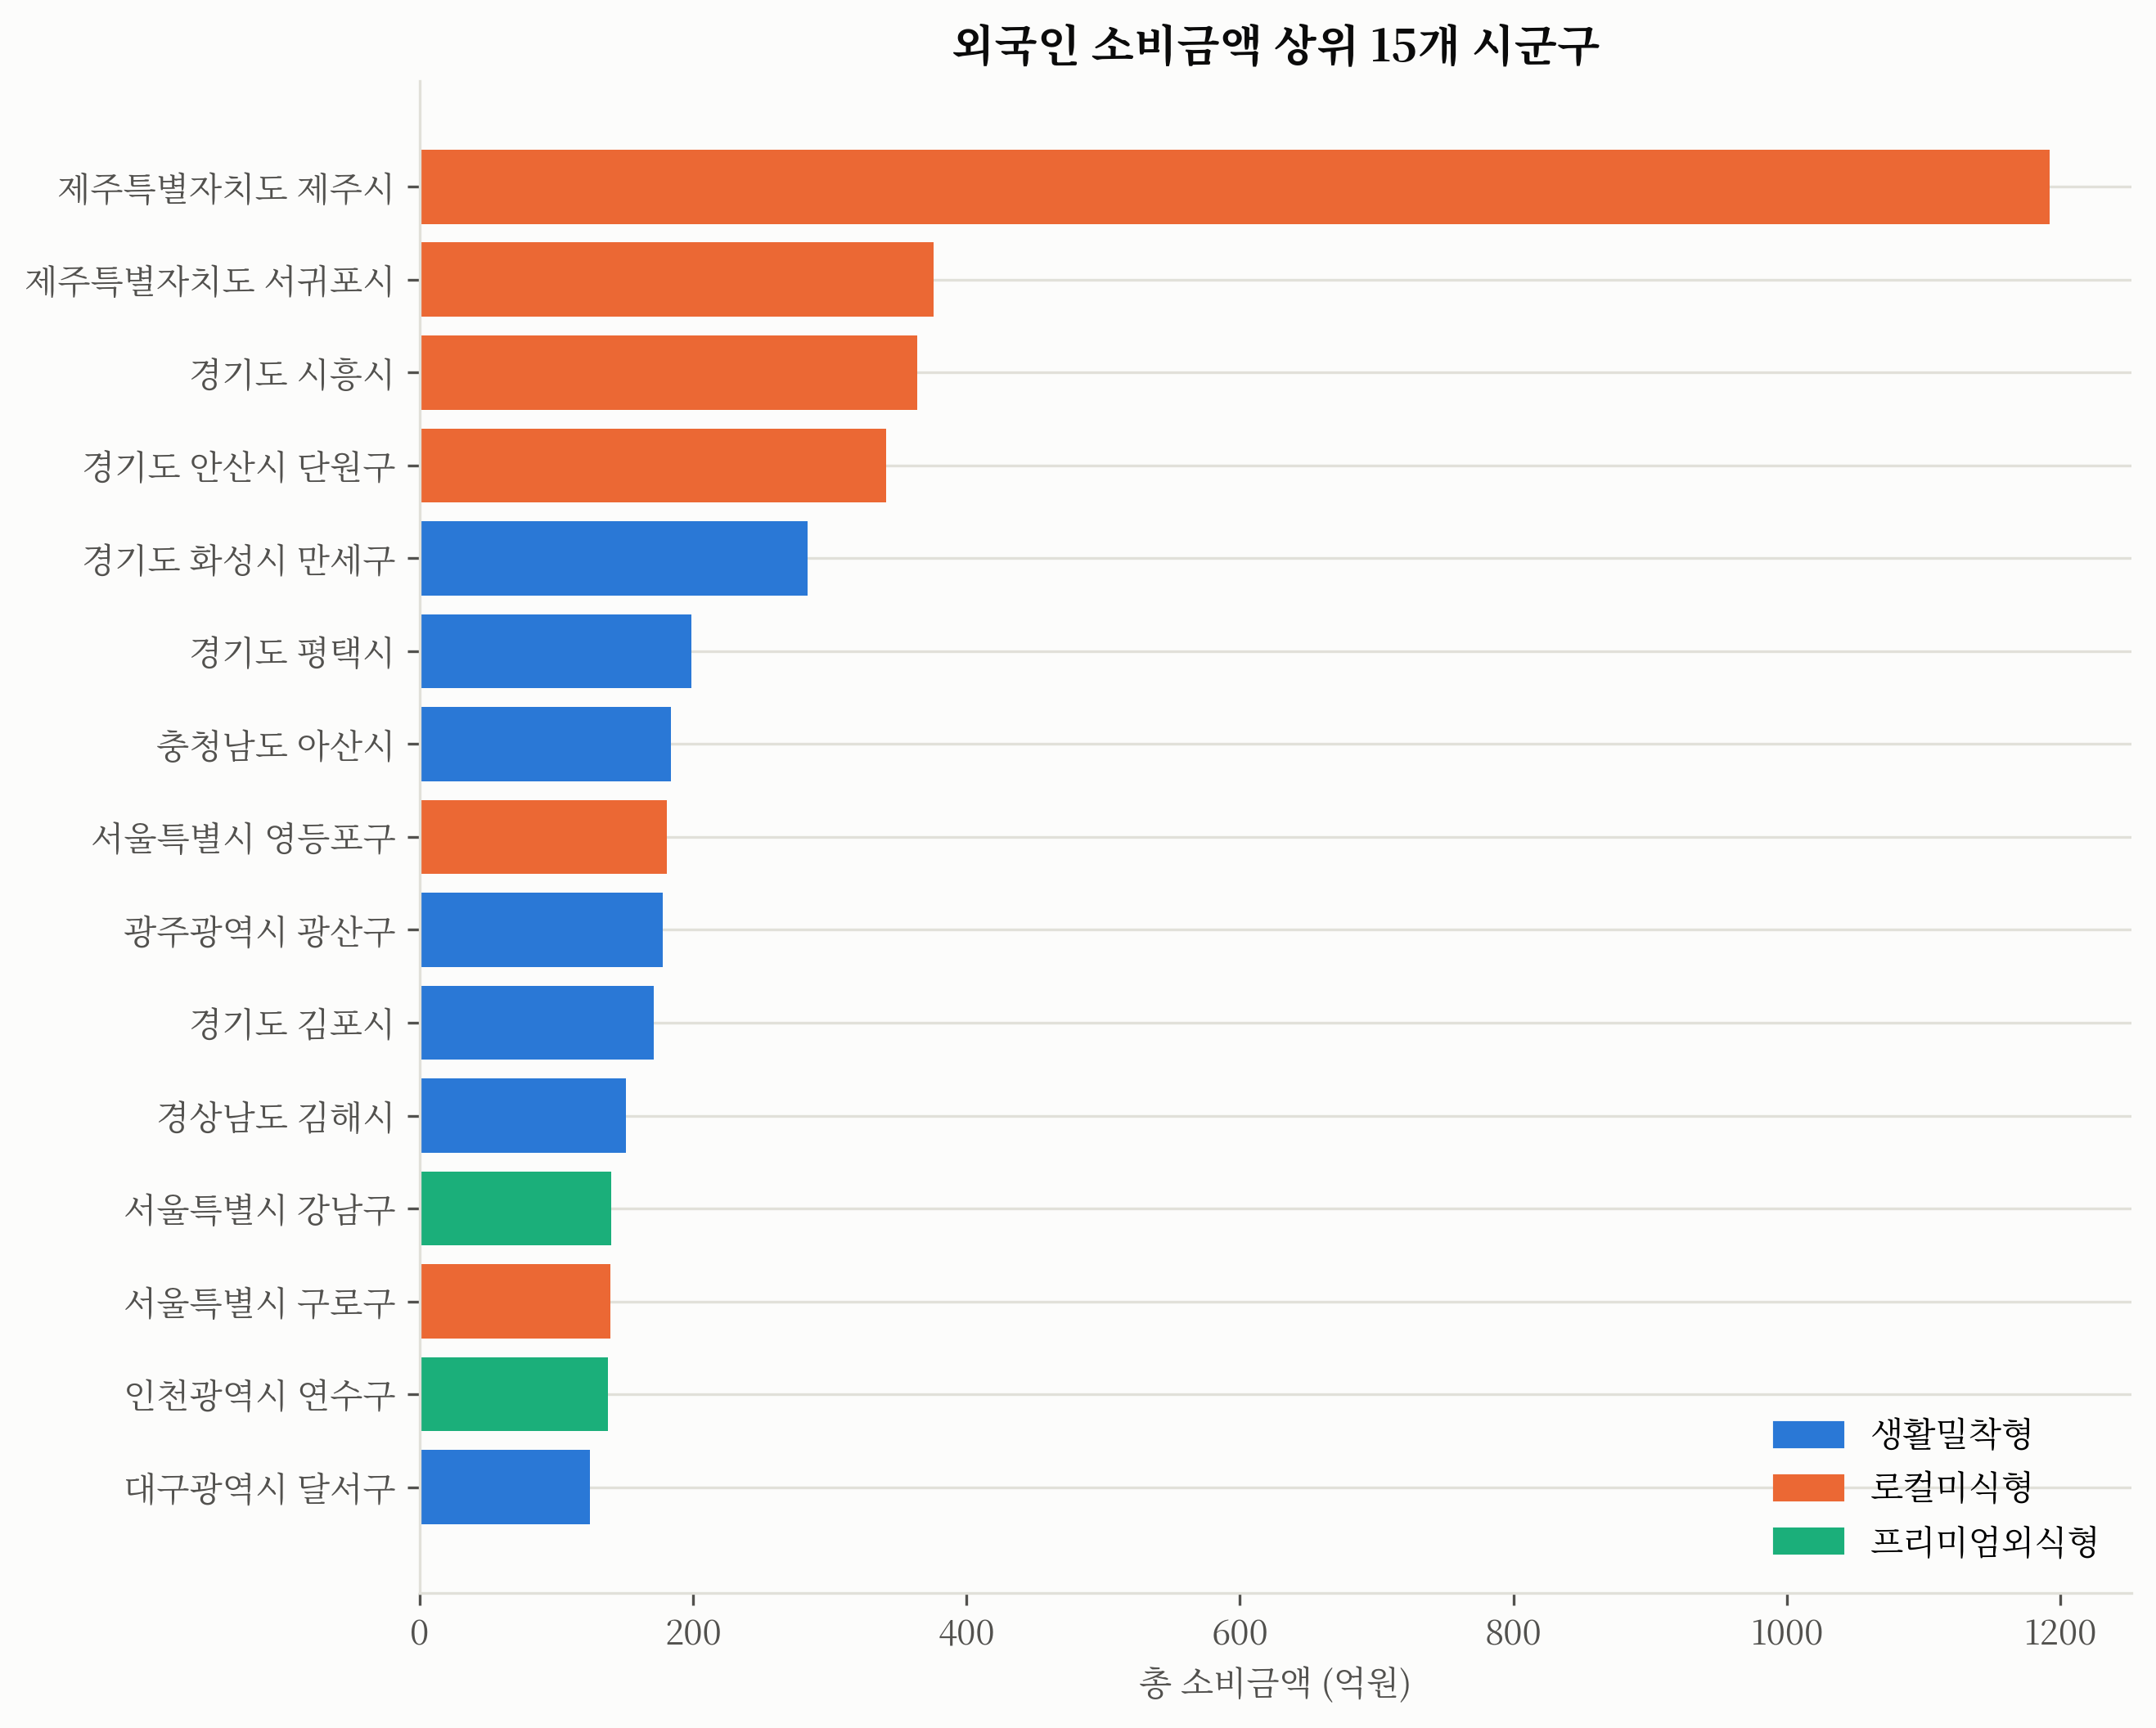

In [4]:
for p in paths:
    display(Image(filename=str(p)))


### 6-2-1. 지도 정적(PNG) 버전

최종 제출물은 PDF 변환이 필요해 인터랙티브 HTML을 담을 수 없으므로, PDF에 바로 삽입 가능한 PNG 버전도 함께 생성한다.

/home/hyunjinhwang/bc-card-data-contest/src/visualize.py:329: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(row["lon"], row["lat"], s=size, color=SEGMENT_COLORS[row["segment"]], alpha=0.75,


[OK] 07_segment_map.png (260 KB)


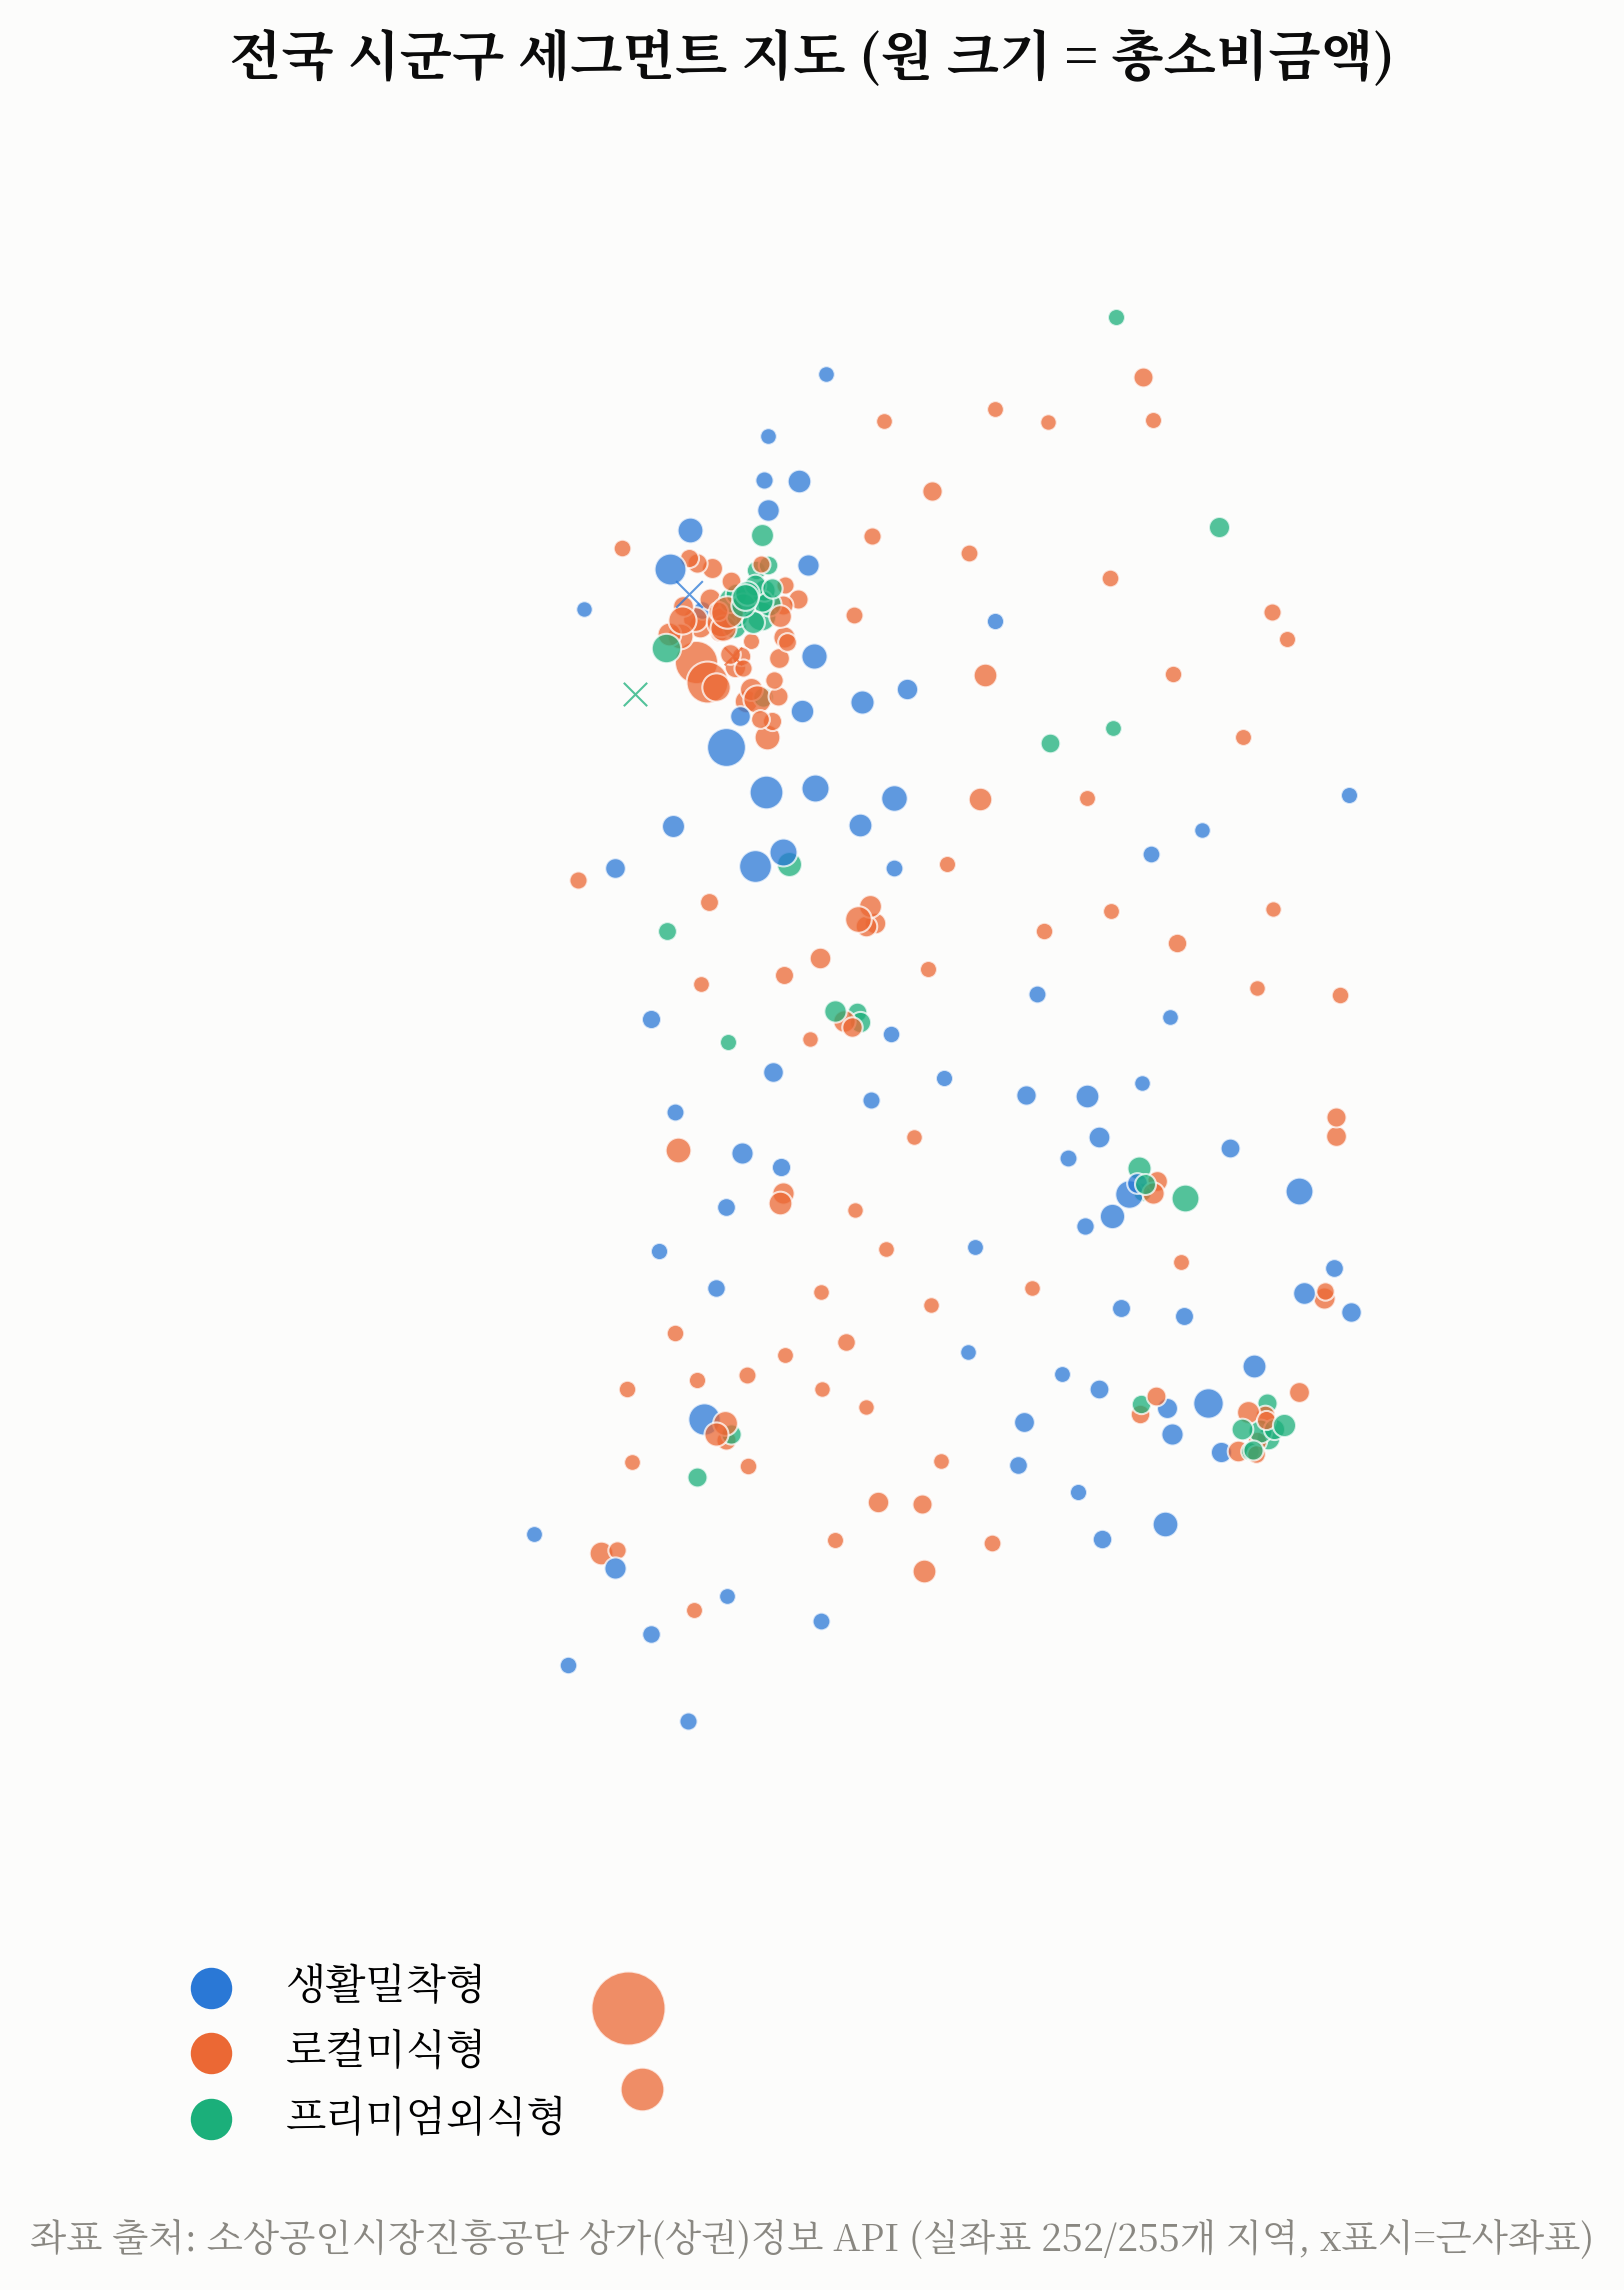

In [5]:
static_map_path = viz.plot_segment_map_static(segment_df)
print(f"[OK] {static_map_path.name} ({static_map_path.stat().st_size/1024:.0f} KB)")
display(Image(filename=str(static_map_path)))


## 6-3. 차트 7: 전국 시군구 세그먼트 지도 (folium)

행정경계 GeoJSON이 제공 데이터에 없어, 시도 대표좌표 기준 원(circle marker) 크기=소비금액, 색상=세그먼트로 표현했다.

In [6]:
map_path = viz.plot_segment_map(segment_df)
print(f"[OK] {map_path.name} ({map_path.stat().st_size/1024:.0f} KB)")
display(IFrame(src=str(map_path), width=900, height=600))


[OK] 07_segment_map.html (279 KB)


## 요약

`results/figures/`에 7개 파일(PNG 6종 + 지도 HTML 1종)이 생성되었다:
1. 세그먼트별 업종 구성비 (누적 막대)
2. 세그먼트별 연령대 분포
3. 월별 소비 추이 (1월=100 지수화)
4. 군집분석 PCA 산점도 (실루엣 스코어 병기)
5. ⭐ 세그먼트별 체류자격 구성비 (Step 4 핵심 결과)
6. 상위 소비 지역 Top 15
7. 전국 시군구 세그먼트 지도

이것으로 노트북 01→06 전체 파이프라인이 완료되었다.